# 📊 Notebook 2: Alert Threshold Optimisation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/early-warning-system-workshop/blob/main/notebooks/02_alert_threshold_optimisation.ipynb)
**DigiHaz Doctoral Training Programme — Module 5: Early Warning System Design**

---

This is the **hands-on exercise** from the workshop. You will work with a synthetic river discharge dataset (based on realistic flood hydrology) to:

1. Explore the threshold dilemma: false alarms vs. missed events
2. Build a ROC curve by testing 100 different alert thresholds
3. Select the cost-optimal threshold using a simple cost function
4. Evaluate system performance using POD, FAR, and CSI
5. Investigate how the optimal threshold changes with seasonal conditions

**This notebook fulfils the Module 5 practical assignment.** Submit your completed notebook (with all cells run) to Moodle.

---

## Setup

In [1]:
# ✅ All libraries below come pre-installed on Google Colab
import importlib, subprocess, sys
needed = ['matplotlib', 'numpy', 'pandas', 'sklearn']
for pkg in needed:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All libraries ready')

✅ All libraries ready


---
## Part 1 — Generate a Synthetic River Discharge Dataset

We simulate 5 years of daily river discharge data for a catchment with:
- Seasonal variability (wet winter, dry summer)
- Random storm events of varying magnitude
- Ground-truth flood labels (discharge > 9 m³/s = flood)

In a real application you would load observed data from a hydrological monitoring station.

In [3]:
import pandas as pd
import numpy as np

np.random.seed(2024)

# 5 years of daily data
n_days = 365 * 5
dates = pd.date_range('2019-01-01', periods=n_days, freq='D')

# Seasonal baseline (higher in winter)
day_of_year = np.array([d.timetuple().tm_yday for d in dates])
seasonal = 3.0 + 2.5 * np.cos(2 * np.pi * (day_of_year - 15) / 365)

# Add random daily variability
noise = np.random.exponential(0.8, n_days)

# Inject storm events (~20 per year, mostly in wet season)
discharge = seasonal + noise
for _ in range(100):  # ~20 storms/year × 5 years
    day = np.random.randint(0, n_days)
    month = dates[day].month
    # Storms more likely and larger in wet season (Oct-Mar)
    if month in [10, 11, 12, 1, 2, 3]:
        magnitude = np.random.uniform(3, 12)
    else:
        magnitude = np.random.uniform(1, 5)
    duration = np.random.randint(2, 7)
    storm_shape = magnitude * np.exp(-np.arange(duration) / 1.5)
    end = min(day + duration, n_days)
    discharge[day:end] += storm_shape[:end-day]

discharge = np.maximum(discharge, 0.5)  # minimum baseflow

# Ground truth: flood = discharge exceeds 9 m³/s
FLOOD_THRESHOLD_TRUE = 9.0
is_flood = (discharge >= FLOOD_THRESHOLD_TRUE).astype(int)

df = pd.DataFrame({'date': dates, 'discharge': discharge, 'is_flood': is_flood})
df['season'] = df['date'].dt.month.map(lambda m: 'Wet' if m in [10,11,12,1,2,3] else 'Dry')

print(f'Dataset: {n_days} days ({n_days/365:.0f} years)')
print(f'Flood days (discharge ≥ {FLOOD_THRESHOLD_TRUE} m³/s): {is_flood.sum()} ({100*is_flood.mean():.1f}%)')
print(f'Mean discharge: {discharge.mean():.2f} m³/s  |  Max: {discharge.max():.2f} m³/s')

Dataset: 1825 days (5 years)
Flood days (discharge ≥ 9.0 m³/s): 89 (4.9%)
Mean discharge: 4.36 m³/s  |  Max: 20.17 m³/s


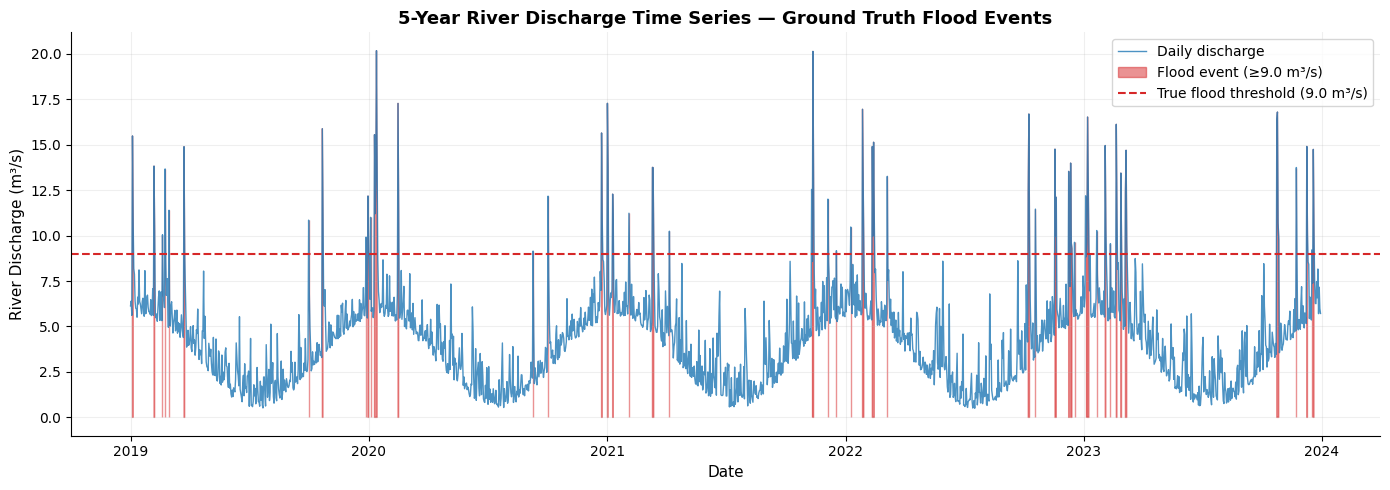

In [5]:
import matplotlib.pyplot as plt

# Define colors used in the plots
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GREEN = '#2ca02c'
RED = '#d62728'
PURPLE = '#9467bd'

# Plot the full 5-year time series
fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')

ax.plot(df['date'], df['discharge'], color=BLUE, lw=1, alpha=0.8, label='Daily discharge')
ax.fill_between(df['date'], df['discharge'], where=df['is_flood']==1,
                color=RED, alpha=0.5, label=f'Flood event (≥{FLOOD_THRESHOLD_TRUE} m³/s)')
ax.axhline(FLOOD_THRESHOLD_TRUE, color=RED, lw=1.5, ls='--', label=f'True flood threshold ({FLOOD_THRESHOLD_TRUE} m³/s)')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('River Discharge (m³/s)', fontsize=11)
ax.set_title('5-Year River Discharge Time Series — Ground Truth Flood Events', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Part 2 — The Threshold Dilemma

We do not know the true flood threshold. An EWS operator must choose an **alert threshold** — the discharge level above which an alert is issued. Let's see what happens at three different settings.

In [6]:
def compute_metrics(discharge, is_flood, threshold):
    """Compute TP, FP, TN, FN and derived metrics for a given threshold."""
    alert = (discharge >= threshold).astype(int)
    TP = int(((alert == 1) & (is_flood == 1)).sum())
    FP = int(((alert == 1) & (is_flood == 0)).sum())
    TN = int(((alert == 0) & (is_flood == 0)).sum())
    FN = int(((alert == 0) & (is_flood == 1)).sum())

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0   # Probability of Detection
    FAR = FP / (FP + TP) if (FP + TP) > 0 else 0   # False Alarm Ratio
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0  # Critical Success Index
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0   # False Positive Rate (for ROC)
    return {'TP':TP,'FP':FP,'TN':TN,'FN':FN,'POD':POD,'FAR':FAR,'CSI':CSI,'FPR':FPR}

# Test three threshold scenarios
scenarios = [
    (5.0,  'Too Sensitive (5 m³/s)',   RED),
    (9.0,  'Optimal (9 m³/s)',          GREEN),
    (13.0, 'Too Conservative (13 m³/s)',BLUE),
]

print(f'{'Scenario':<35} {'Threshold':>10} {'POD':>8} {'FAR':>8} {'CSI':>8} {'False Alarms/yr':>16} {'Missed Floods/yr':>17}')
print('-'*104)
for thresh, label, _ in scenarios:
    m = compute_metrics(discharge, is_flood, thresh)
    fa_per_year = m['FP'] / 5
    miss_per_year = m['FN'] / 5
    print(f'{label:<35} {thresh:>10.1f} {m["POD"]:>8.3f} {m["FAR"]:>8.3f} {m["CSI"]:>8.3f} {fa_per_year:>16.1f} {miss_per_year:>17.1f}')

Scenario                             Threshold      POD      FAR      CSI  False Alarms/yr  Missed Floods/yr
--------------------------------------------------------------------------------------------------------
Too Sensitive (5 m³/s)                     5.0    1.000    0.871    0.129            120.6               0.0
Optimal (9 m³/s)                           9.0    1.000    0.000    1.000              0.0               0.0
Too Conservative (13 m³/s)                13.0    0.382    0.000    0.382              0.0              11.0


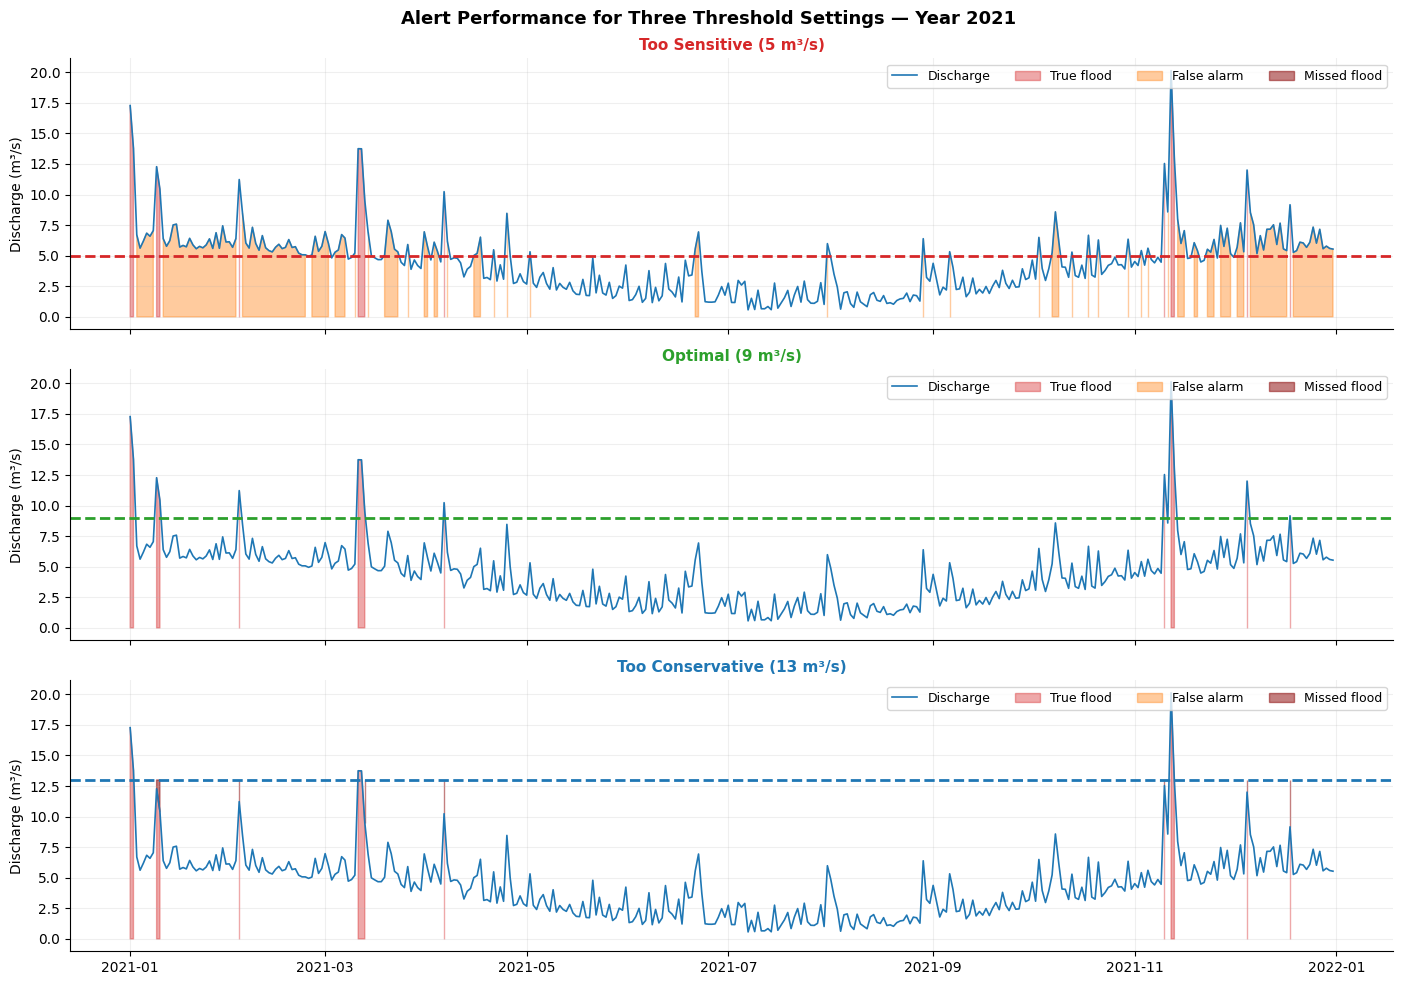

In [7]:
# Visualise a 1-year zoom for each threshold
year_mask = df['date'].dt.year == 2021
df_year = df[year_mask]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor='white', sharex=True)

for ax, (thresh, label, col) in zip(axes, scenarios):
    alert = df_year['discharge'] >= thresh
    ax.plot(df_year['date'], df_year['discharge'], color=BLUE, lw=1.2, label='Discharge')
    ax.fill_between(df_year['date'], df_year['discharge'],
                    where=df_year['is_flood']==1,
                    color=RED, alpha=0.4, label='True flood')
    ax.fill_between(df_year['date'], df_year['discharge'],
                    where=alert & (df_year['is_flood']==0),
                    color=ORANGE, alpha=0.4, label='False alarm')
    ax.fill_between(df_year['date'], thresh, df_year['discharge'],
                    where=~alert & (df_year['is_flood']==1),
                    color='#880000', alpha=0.5, label='Missed flood')
    ax.axhline(thresh, color=col, lw=2, ls='--')
    ax.set_ylabel('Discharge (m³/s)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=col)
    ax.legend(fontsize=9, loc='upper right', ncol=4)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Alert Performance for Three Threshold Settings — Year 2021', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Building the ROC Curve

Instead of testing just 3 thresholds, we test **100 thresholds** and plot the full ROC curve. Each point on the curve represents one threshold setting.

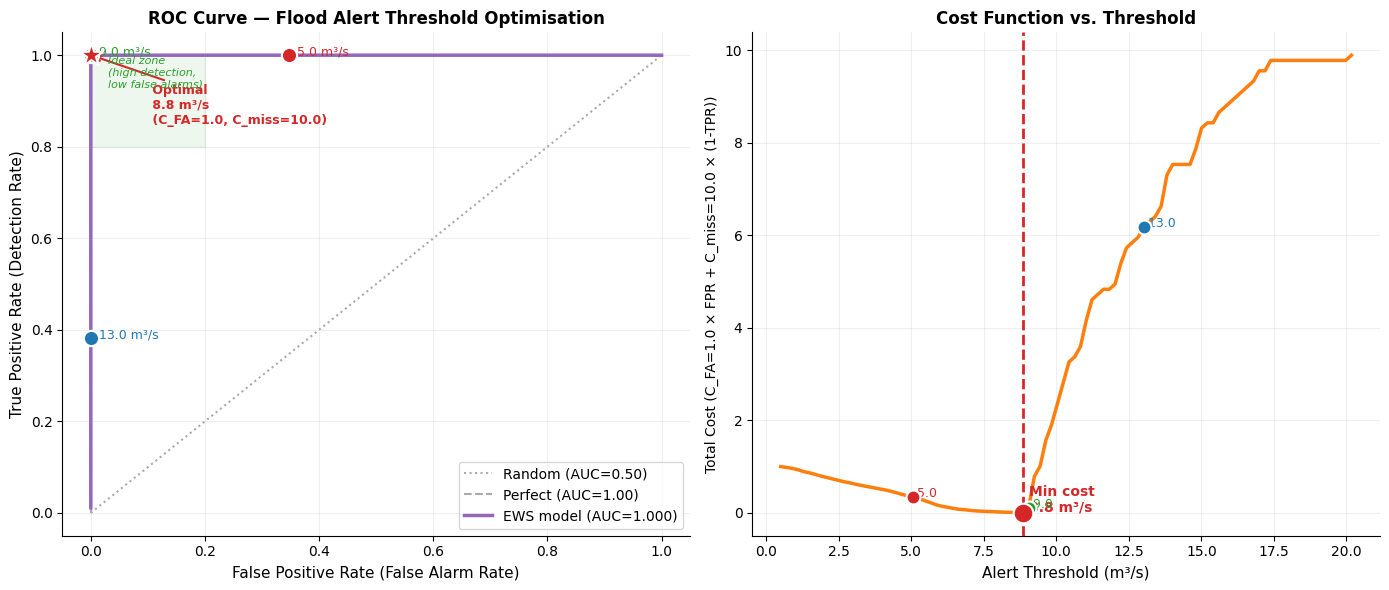

Optimal threshold: 8.85 m³/s (C_FA=1.0, C_miss=10.0)
POD=1.000 | FAR=0.011 | CSI=0.989
False alarms/year: 0.2 | Missed floods/year: 0.0


In [9]:
from sklearn.metrics import auc

# Compute ROC curve across 100 thresholds
thresholds = np.linspace(discharge.min(), discharge.max(), 100)
fprs, tprs, pods, fars, csis = [], [], [], [], []

for t in thresholds:
    m = compute_metrics(discharge, is_flood, t)
    fprs.append(m['FPR'])
    tprs.append(m['POD'])
    pods.append(m['POD'])
    fars.append(m['FAR'])
    csis.append(m['CSI'])

fprs, tprs = np.array(fprs), np.array(tprs)
roc_auc = auc(fprs, tprs)

# ── COST FUNCTION ──────────────────────────────────────────────────────────
# Change these values to explore how the optimal point shifts
C_FALSE_ALARM = 1.0    # relative cost of a false alarm
C_MISSED      = 10.0   # relative cost of a missed flood (higher = lives at risk)
# ──────────────────────────────────────────────────────────────────────────

costs = C_FALSE_ALARM * np.array(fprs) + C_MISSED * (1 - np.array(tprs))
optimal_idx = np.argmin(costs)
optimal_thresh = thresholds[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# --- Left: ROC curve ---
ax = axes[0]
ax.plot([0,1],[0,1],':', color='#aaa', lw=1.5, label='Random (AUC=0.50)')
ax.plot([0,0,1],[0,1,1],'--', color='#aaa', lw=1.5, label='Perfect (AUC=1.00)')
ax.plot(fprs, tprs, color=PURPLE, lw=2.5, label=f'EWS model (AUC={roc_auc:.3f})')

# Mark the three scenario points
for thresh, label, col in scenarios:
    m = compute_metrics(discharge, is_flood, thresh)
    ax.scatter(m['FPR'], m['POD'], s=120, c=col, zorder=6, edgecolors='white', lw=1.5)
    ax.annotate(f'  {thresh} m³/s', xy=(m['FPR'], m['POD']), fontsize=9, color=col)

# Mark optimal point
ax.scatter(fprs[optimal_idx], tprs[optimal_idx], s=300, c=RED,
           marker='*', zorder=7, edgecolors='white', lw=1.5)
ax.annotate(f' Optimal\n {optimal_thresh:.1f} m³/s\n (C_FA={C_FALSE_ALARM}, C_miss={C_MISSED})',
            xy=(fprs[optimal_idx], tprs[optimal_idx]),
            xytext=(fprs[optimal_idx]+0.1, tprs[optimal_idx]-0.15),
            fontsize=9, color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

ax.fill_between([0, 0.2], [0.8, 0.8], [1, 1], alpha=0.08, color=GREEN)
ax.text(0.03, 0.93, 'Ideal zone\n(high detection,\nlow false alarms)',
        fontsize=8, color=GREEN, fontstyle='italic')

ax.set_xlabel('False Positive Rate (False Alarm Rate)', fontsize=11)
ax.set_ylabel('True Positive Rate (Detection Rate)', fontsize=11)
ax.set_title('ROC Curve — Flood Alert Threshold Optimisation', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# --- Right: Cost curve ---
ax2 = axes[1]
ax2.plot(thresholds, costs, color=ORANGE, lw=2.5)
ax2.axvline(optimal_thresh, color=RED, lw=2, ls='--')
ax2.scatter([optimal_thresh], [costs[optimal_idx]], s=200, c=RED,
            zorder=6, edgecolors='white', lw=1.5)
ax2.text(optimal_thresh+0.2, costs[optimal_idx]+0.02,
         f'Min cost\n{optimal_thresh:.1f} m³/s',
         fontsize=10, color=RED, fontweight='bold')
for thresh, label, col in scenarios:
    idx = np.argmin(np.abs(thresholds - thresh))
    ax2.scatter([thresholds[idx]], [costs[idx]], s=100, c=col, zorder=5,
                edgecolors='white', lw=1.5)
    ax2.annotate(f' {thresh}', xy=(thresholds[idx], costs[idx]), fontsize=9, color=col)

ax2.set_xlabel('Alert Threshold (m³/s)', fontsize=11)
ax2.set_ylabel(f'Total Cost (C_FA={C_FALSE_ALARM} × FPR + C_miss={C_MISSED} × (1-TPR))', fontsize=10)
ax2.set_title('Cost Function vs. Threshold', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

m_opt = compute_metrics(discharge, is_flood, optimal_thresh)
print(f'Optimal threshold: {optimal_thresh:.2f} m³/s (C_FA={C_FALSE_ALARM}, C_miss={C_MISSED})')
print(f'POD={m_opt["POD"]:.3f} | FAR={m_opt["FAR"]:.3f} | CSI={m_opt["CSI"]:.3f}')
print(f'False alarms/year: {m_opt["FP"]/5:.1f} | Missed floods/year: {m_opt["FN"]/5:.1f}')

---
## Part 4 — Seasonal Threshold Analysis (Extension)

Should the alert threshold be the same all year round? Let's compare the optimal threshold in **wet season** (Oct–Mar) vs. **dry season** (Apr–Sep).

Wet Season (Oct–Mar): 910 days, 87 flood days (9.6%)
  Optimal threshold: 8.93 m³/s | AUC: 1.000

Dry Season (Apr–Sep): 915 days, 2 flood days (0.2%)
  Optimal threshold: 8.67 m³/s | AUC: 1.000



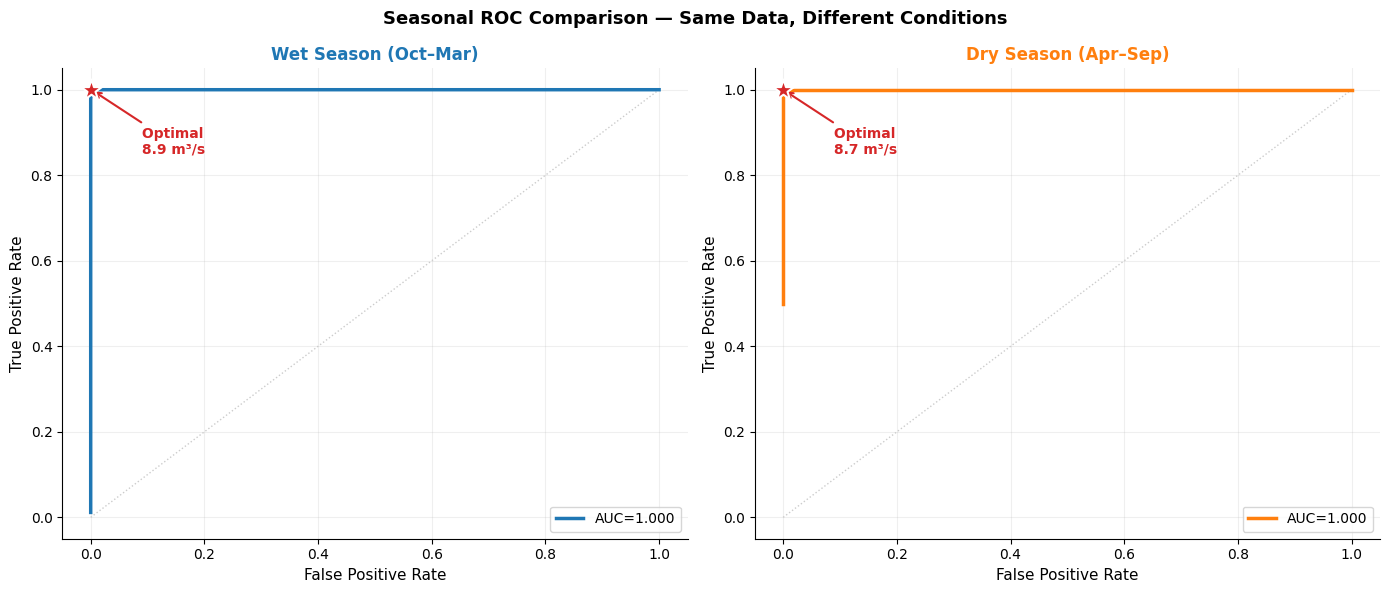

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

seasons_config = [
    ('Wet Season (Oct–Mar)', df['season'] == 'Wet', BLUE,   axes[0]),
    ('Dry Season (Apr–Sep)', df['season'] == 'Dry', ORANGE, axes[1]),
]

for season_label, mask, col, ax in seasons_config:
    d_s = df.loc[mask, 'discharge'].values
    f_s = df.loc[mask, 'is_flood'].values

    t_range = np.linspace(d_s.min(), d_s.max(), 100)
    fprs_s, tprs_s, costs_s = [], [], []
    for t in t_range:
        m = compute_metrics(d_s, f_s, t)
        fprs_s.append(m['FPR']); tprs_s.append(m['POD'])
        costs_s.append(C_FALSE_ALARM * m['FPR'] + C_MISSED * (1 - m['POD']))

    fprs_s, tprs_s = np.array(fprs_s), np.array(tprs_s)
    opt_idx_s = np.argmin(costs_s)
    auc_s = auc(fprs_s, tprs_s)

    ax.plot([0,1],[0,1],':', color='#ccc', lw=1)
    ax.plot(fprs_s, tprs_s, color=col, lw=2.5, label=f'AUC={auc_s:.3f}')
    ax.scatter(fprs_s[opt_idx_s], tprs_s[opt_idx_s], s=250, c=RED,
               marker='*', zorder=6, edgecolors='white', lw=1.5)
    ax.annotate(f' Optimal\n {t_range[opt_idx_s]:.1f} m³/s',
                xy=(fprs_s[opt_idx_s], tprs_s[opt_idx_s]),
                xytext=(fprs_s[opt_idx_s]+0.08, tprs_s[opt_idx_s]-0.15),
                fontsize=10, color=RED, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(season_label, fontsize=12, fontweight='bold', color=col)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    n_floods = f_s.sum()
    print(f'{season_label}: {len(d_s)} days, {n_floods} flood days ({100*n_floods/len(d_s):.1f}%)')
    print(f'  Optimal threshold: {t_range[opt_idx_s]:.2f} m³/s | AUC: {auc_s:.3f}\n')

fig.suptitle('Seasonal ROC Comparison — Same Data, Different Conditions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✏️ Assignment: Write Your Reflection

Replace the placeholder text below with your answers (250 words minimum). This cell is a Markdown cell — double-click to edit.

### Student Reflection

**Student name:** [Your name here]

**Question 1:** In Part 3 with C_FA=1 and C_miss=10, what is the optimal threshold? Now change C_FA=1 and C_miss=1 and re-run the cell. How does the optimal threshold change, and why?

> *[Your answer here — minimum 100 words]*

**Question 2:** The seasonal analysis in Part 4 shows different optimal thresholds for wet and dry seasons. What operational recommendation would you make to the EWS operator? What are the risks of using a single threshold year-round?

> *[Your answer here — minimum 100 words]*

**Question 3:** This exercise used a single threshold on a single variable (discharge). Name two limitations of this approach for a real-world EWS and suggest how they could be addressed.

> *[Your answer here — minimum 50 words]*

---
## Summary: Your Results Table

Run the cell below to generate a clean summary table of your findings.

In [11]:
results = []
for thresh, label, _ in scenarios:
    m = compute_metrics(discharge, is_flood, thresh)
    results.append({'Threshold (m³/s)': thresh, 'Scenario': label,
                    'POD': round(m['POD'],3), 'FAR': round(m['FAR'],3),
                    'CSI': round(m['CSI'],3),
                    'False alarms/yr': round(m['FP']/5,1),
                    'Missed floods/yr': round(m['FN']/5,1)})

m_opt = compute_metrics(discharge, is_flood, optimal_thresh)
results.append({'Threshold (m³/s)': round(optimal_thresh,2), 'Scenario': f'Cost-optimal (C_FA={C_FALSE_ALARM}, C_miss={C_MISSED})',
                'POD': round(m_opt['POD'],3), 'FAR': round(m_opt['FAR'],3),
                'CSI': round(m_opt['CSI'],3),
                'False alarms/yr': round(m_opt['FP']/5,1),
                'Missed floods/yr': round(m_opt['FN']/5,1)})

results_df = pd.DataFrame(results)
print('\n=== YOUR RESULTS ===')
print(results_df.to_string(index=False))
print(f'\nROC AUC (all data): {roc_auc:.4f}')


=== YOUR RESULTS ===
 Threshold (m³/s)                             Scenario   POD   FAR   CSI  False alarms/yr  Missed floods/yr
             5.00               Too Sensitive (5 m³/s) 1.000 0.871 0.129            120.6               0.0
             9.00                     Optimal (9 m³/s) 1.000 0.000 1.000              0.0               0.0
            13.00           Too Conservative (13 m³/s) 0.382 0.000 0.382              0.0              11.0
             8.85 Cost-optimal (C_FA=1.0, C_miss=10.0) 1.000 0.011 0.989              0.2               0.0

ROC AUC (all data): 1.0000


---
*DigiHaz Module 5 — Notebook 2 of 3 | github.com/Digihaz/early-warning-system-workshop*

**Submission:** Save this notebook (File → Save) and upload to Moodle Module 5 assignment.